# Financial QA Pipeline — Analysis Notebook

**PwC Senior Machine Learning Associate — Take-Home Assessment**

This notebook presents a reproducible evaluation pipeline for financial QA on 10-K filings:

1. Load the dataset and select exactly 50 samples
2. Run two candidate models (`gpt-4.1` and `gpt-4.1-mini`)
3. Evaluate answer quality, numerical correctness, abstention behaviour, and operational trade-offs
4. Compare results and make a production recommendation
5. Export tables and charts for the final slides

**Mocked outputs:** None. All prediction outputs were generated from live OpenAI API calls.

**Requirements:** install the project dependencies from the README and ensure `OPENAI_API_KEY` is set before running the pipeline cells.

In [1]:
import sys
import json
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (10, 5)
plt.style.use('seaborn-v0_8-whitegrid')

# Ensure src is importable
sys.path.insert(0, str(Path.cwd().parent) if Path.cwd().name == "notebooks" else str(Path.cwd()))

from src.data_loader import load_sample
from src.pipeline import run_full_pipeline
from src.evaluation import evaluate_predictions, save_evaluation

# Config
MODELS = ["gpt-4.1", "gpt-4.1-mini"]
SAMPLE_SIZE = 50
SEED = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup complete.")
print(f"OPENAI_API_KEY set: {'Yes' if os.environ.get('OPENAI_API_KEY') else 'NO — set it before running the pipeline'}")


Setup complete.
OPENAI_API_KEY set: Yes


## 1. Dataset Exploration

Before selecting our 50 samples, we explore the full dataset to understand its structure.

In [2]:
from src.data_loader import load_dataset, load_sample, classify_answer_type, ROOT
import pandas as pd

full_df = load_dataset(ROOT / 'Financial-QA-10k.csv')

print(f'Shape: {full_df.shape}')
print(f'Columns: {list(full_df.columns)}')
print(f'\nNull values:')
print(full_df[['question', 'answer', 'context']].isnull().sum())
print(f'\nUnique tickers: {full_df["ticker"].nunique()}')
print(f'Unique filings: {full_df["filing"].nunique()}')
print(f'\nTicker distribution (top 10):')
print(full_df['ticker'].value_counts().head(10))
print(f'\nAnswer type distribution:')
print(full_df['answer_type'].value_counts())
print(f"Context length — median: {full_df['context'].str.len().median():.0f}, max: {full_df['context'].str.len().max():.0f} chars")
print(f"Answer length  — median: {full_df['answer'].str.len().median():.0f}, max: {full_df['answer'].str.len().max():.0f} chars")

Shape: (6997, 6)
Columns: ['question', 'answer', 'context', 'ticker', 'filing', 'answer_type']

Null values:
question    0
answer      0
context     0
dtype: int64

Unique tickers: 69
Unique filings: 1

Ticker distribution (top 10):
ticker
JNJ      200
NVDA     100
AAPL     100
TSLA     100
LULU     100
PG       100
COST     100
ABNB     100
MSFT     100
BRK-A    100
Name: count, dtype: int64

Answer type distribution:
answer_type
long_text     4818
numeric       1250
short_text     929
Name: count, dtype: int64
Context length — median: 177, max: 5585 chars
Answer length  — median: 115, max: 738 chars


### 1.1 Should we just take the first 50 rows?

The brief says "selecting the first 50 entries is acceptable". Before doing that, let's check what those first 50 rows actually look like.


In [3]:
first_50 = full_df.head(50)

print(f'Shape: {first_50.shape}')
print(f'\nUnique tickers: {first_50["ticker"].nunique()}')
print(first_50['ticker'].value_counts())
print(f'\nUnique filings: {first_50["filing"].nunique()}')
print(first_50['filing'].unique())
print(f'\nAnswer type distribution:')
print(first_50['answer_type'].value_counts())

Shape: (50, 6)

Unique tickers: 1
ticker
NVDA    50
Name: count, dtype: int64

Unique filings: 1
<StringArray>
['2023_10K']
Length: 1, dtype: str

Answer type distribution:
answer_type
long_text     44
short_text     4
numeric        2
Name: count, dtype: int64


## 2. Sampling Strategy

The brief states that “selecting the first 50 entries is acceptable”, but the exploration above shows that this would yield 50 NVIDIA-only questions with limited answer-type diversity.

Instead, I use **stratified sampling** with a fixed seed (`42`) for reproducibility:

1. **Answer type balance** — allocate a mix of numeric, short-text, and long-text answers so the evaluation covers the main QA patterns in the dataset.
2. **Ticker diversity** — within each answer type, sample across as many companies as possible before backfilling from remaining rows.

This gives a more representative 50-sample evaluation set while staying lightweight and easy to reproduce. Numeric answers support the numerical accuracy metric, short answers test exact-match style behaviour, and longer answers test token overlap and ROUGE-L.


In [4]:
SAMPLE_PATH = OUTPUT_DIR / "samples.csv"

if SAMPLE_PATH.exists():
    samples = pd.read_csv(SAMPLE_PATH)
    print(f"Loaded frozen sample: {samples.shape[0]} rows")
else:
    samples = load_sample(n=SAMPLE_SIZE, seed=SEED)
    samples.to_csv(SAMPLE_PATH, index=False)
    print(f"Generated and saved sample: {samples.shape[0]} rows")

print(f"Unique tickers: {samples['ticker'].nunique()} (vs 1 with naive sampling)")
print(f"\nAnswer type distribution:")
print(samples['answer_type'].value_counts())
print(f"\nTickers: {sorted(samples['ticker'].unique())}")
samples.head()

Generated and saved sample: 50 rows
Unique tickers: 43 (vs 1 with naive sampling)

Answer type distribution:
answer_type
long_text     34
numeric        8
short_text     8
Name: count, dtype: int64

Tickers: ['AAPL', 'ABNB', 'AMC', 'AMZN', 'AVGO', 'AXP', 'BRK-A', 'CAT', 'CVS', 'CVX', 'DVA', 'EA', 'EFX', 'ETSY', 'F', 'GILD', 'GME', 'GOOGL', 'GS', 'HLT', 'HPE', 'HPQ', 'IBM', 'ICE', 'INTU', 'IRM', 'JNJ', 'JPM', 'KO', 'KR', 'LLY', 'LVS', 'META', 'MSFT', 'NFLX', 'NKE', 'NVDA', 'PTON', 'SCHW', 'T', 'TSLA', 'V', 'WMT']


,sample_id,question,answer,context,ticker,filing,answer_type
0,0,How much did the total operating lease assets ...,$4.4 billion,"For the years ended December 31, 2022 and 2023...",GOOGL,2023_10K,numeric
1,1,What are the restructuring targets of the comp...,The restructuring targets for 2023 focus on pr...,"In March 2023, the Board of Directors sanction...",EA,2023_10K,long_text
2,2,What is the significance of Note 13 in the con...,Note 13 is significant because it contains a d...,For a description of our significant pending l...,GILD,2023_10K,long_text
3,3,How many employees does Johnson & Johnson and ...,"Approximately 131,900 employees",Johnson & Johnson and its subsidiaries have ap...,JNJ,2023_10K,short_text
4,4,How does IBM's service and product offerings i...,IBM offers a unique blend of software and cons...,"The depth, breadth, and innovation of our soft...",IBM,2023_10K,long_text


### 2.1 Sample Composition Plots

Quick visual check that the stratified sample has the intended answer-type and length distribution.


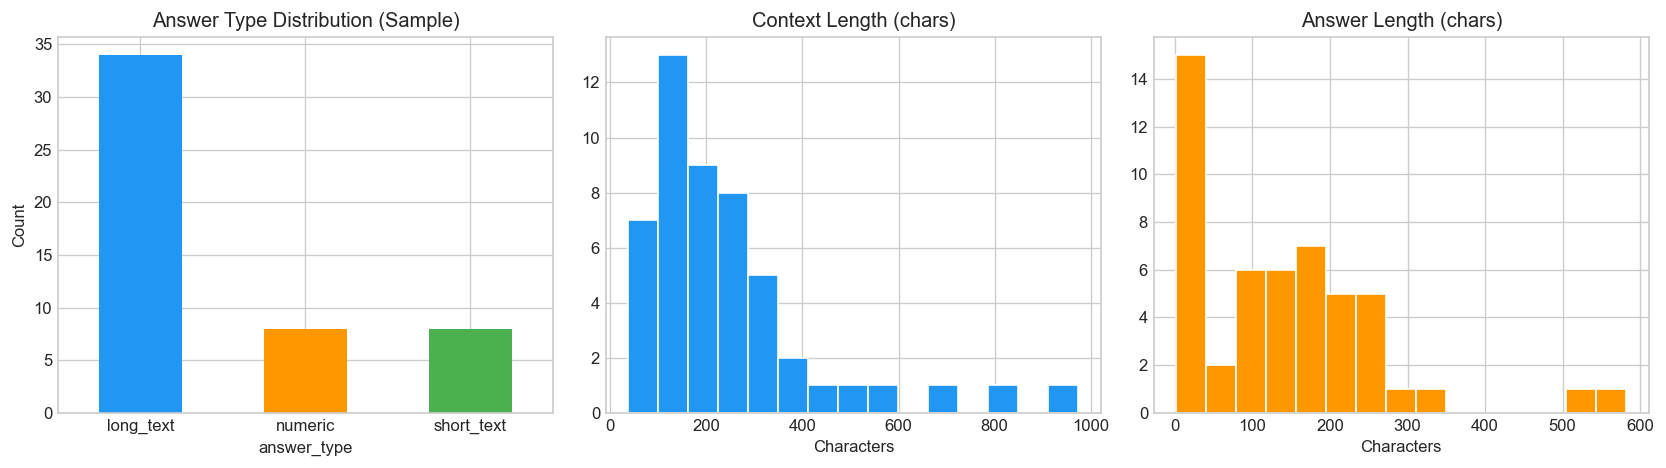

Context length — median: 198 chars, max: 974 chars
Answer length  — median: 130 chars, max: 582 chars


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Answer type distribution (sample)
samples['answer_type'].value_counts().plot.bar(ax=axes[0], color=['#2196F3', '#FF9800', '#4CAF50'])
axes[0].set_title('Answer Type Distribution (Sample)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Context length distribution (sample)
samples['context'].str.len().hist(ax=axes[1], bins=15, color='#2196F3', edgecolor='white')
axes[1].set_title('Context Length (chars)')
axes[1].set_xlabel('Characters')

# Answer length distribution (sample)
samples['answer'].str.len().hist(ax=axes[2], bins=15, color='#FF9800', edgecolor='white')
axes[2].set_title('Answer Length (chars)')
axes[2].set_xlabel('Characters')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_exploration.png', bbox_inches='tight')
plt.show()
print(f"Context length — median: {samples['context'].str.len().median():.0f} chars, max: {samples['context'].str.len().max():.0f} chars")
print(f"Answer length  — median: {samples['answer'].str.len().median():.0f} chars, max: {samples['answer'].str.len().max():.0f} chars")

## 3. Run Pipeline

Call both GPT-4.1 and GPT-4.1 Mini on all 50 samples. Each call uses Structured Outputs (JSON schema enforcement) with temperature=0 for reproducibility.


In [ ]:
# This cell calls the OpenAI API on first run only.
# Subsequent runs load cached predictions from disk.
# Estimated cost: ~$0.13 total for both models (GPT-4.1 ≈ $0.11, Mini ≈ $0.02).

existing = {}
for model in MODELS:
    safe_name = model.replace("/", "_").replace(".", "-")
    path = OUTPUT_DIR / f"predictions_{safe_name}.jsonl"
    if path.exists():
        existing[model] = str(path)
        print(f"⏭️  {model}: predictions exist at {path}, skipping API call")

if len(existing) == len(MODELS):
    output_paths = existing
    print("\n✅ All predictions loaded from disk (no API calls made)")
else:
    models_to_run = [m for m in MODELS if m not in existing]
    new_paths = run_full_pipeline(
        samples=samples,
        models=models_to_run,
        output_dir=str(OUTPUT_DIR),
        temperature=0.0,
        verbose=False,
    )
    output_paths = {**existing, **new_paths}
    print("\n✅ Pipeline complete. Output files:")
    for model, path in output_paths.items():
        print(f"  {model}: {path}")


Running model: gpt-4.1
Saved 50 predictions to /Users/agbajames/financial-qa-pipeline/outputs/predictions_gpt-4-1.jsonl

Summary for gpt-4.1:
  Answered:     48/50
  Abstained:    2/50
  Errors:       0/50
  Avg latency:  1770ms
  Total tokens: 39,091

Running model: gpt-4.1-mini
Saved 50 predictions to /Users/agbajames/financial-qa-pipeline/outputs/predictions_gpt-4-1-mini.jsonl

Summary for gpt-4.1-mini:
  Answered:     48/50
  Abstained:    2/50
  Errors:       0/50
  Avg latency:  2705ms
  Total tokens: 39,259

✅ Pipeline complete. Output files:
  gpt-4.1: /Users/agbajames/financial-qa-pipeline/outputs/predictions_gpt-4-1.jsonl
  gpt-4.1-mini: /Users/agbajames/financial-qa-pipeline/outputs/predictions_gpt-4-1-mini.jsonl


## 4. Load Predictions & Evaluate

Load the saved JSONL outputs and run an evaluation suite focused on:
- lexical overlap (`Token F1`, `ROUGE-L`, with `Exact Match` as a strict supporting metric)
- numerical correctness for figure-based answers
- abstention behaviour
- latency and token usage


In [7]:
def load_predictions(path):
    """Load JSONL predictions into a list of dicts."""
    records = []
    with open(path) as f:
        for line in f:
            records.append(json.loads(line))
    return records

# Load both sets of predictions
all_results = {}
for model in MODELS:
    safe_name = model.replace("/", "_").replace(".", "-")
    path = OUTPUT_DIR / f"predictions_{safe_name}.jsonl"
    records = load_predictions(path)
    print(f"Loaded {len(records)} predictions for {model}")
    all_results[model] = records

Loaded 50 predictions for gpt-4.1
Loaded 50 predictions for gpt-4.1-mini


In [ ]:
# Run evaluation for each model

evaluations = {}
for model in MODELS:
    print(f"\n{'='*50}")
    print(f"Evaluating: {model}")
    print(f"{'='*50}")

    eval_result = evaluate_predictions(
        records=all_results[model],
        verbose=False,
    )
    evaluations[model] = eval_result

    # Save evaluation outputs
    save_evaluation(eval_result, model_name=model, output_dir=str(OUTPUT_DIR))

print("\n✅ Evaluation complete.")



Evaluating: gpt-4.1
Saved evaluation for gpt-4.1:
  Summary: /Users/agbajames/financial-qa-pipeline/outputs/eval_summary_gpt-4-1.json
  Details: /Users/agbajames/financial-qa-pipeline/outputs/eval_details_gpt-4-1.csv

Evaluating: gpt-4.1-mini
Saved evaluation for gpt-4.1-mini:
  Summary: /Users/agbajames/financial-qa-pipeline/outputs/eval_summary_gpt-4-1-mini.json
  Details: /Users/agbajames/financial-qa-pipeline/outputs/eval_details_gpt-4-1-mini.csv

✅ Evaluation complete.


## 5. Model Comparison

### 5.1 Summary Table


In [9]:
# Build the main comparison table used in the slides
comparison_rows = []

for model in MODELS:
    summary = evaluations[model]["summary"]
    abstention = evaluations[model]["abstention"]

    comparison_rows.append(
        {
            "Model": model,
            "Coverage": abstention["coverage"],
            "Answered": summary["n_answered"],
            "Abstained": summary["n_abstained"],
            "Exact Match": summary["mean_exact_match"],
            "Token F1": summary["mean_token_f1"],
            "ROUGE-L": summary["mean_rouge_l"],
            "Numerical Accuracy": summary["mean_numerical_accuracy"],
            "Should-Have-Abstained Rate": abstention["should_have_abstained_rate"],
            "Avg Latency (ms)": summary["mean_latency_ms"],
            "Total Tokens": summary["total_tokens"],
        }
    )

comparison_table = pd.DataFrame(comparison_rows).set_index("Model")

display_table = comparison_table.copy()
for col in ["Coverage", "Exact Match", "Numerical Accuracy", "Should-Have-Abstained Rate"]:
    display_table[col] = display_table[col].apply(lambda x: f"{x:.0%}" if pd.notna(x) else "N/A")
for col in ["Token F1", "ROUGE-L"]:
    display_table[col] = display_table[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")
display_table["Avg Latency (ms)"] = display_table["Avg Latency (ms)"].apply(lambda x: f"{x:.0f}" if pd.notna(x) else "N/A")
display_table["Total Tokens"] = display_table["Total Tokens"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "N/A")

print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
display_table.T


MODEL COMPARISON SUMMARY


Model,gpt-4.1,gpt-4.1-mini
Coverage,96%,96%
Answered,48,48
Abstained,2,2
Exact Match,25%,29%
Token F1,0.730,0.767
ROUGE-L,0.712,0.752
Numerical Accuracy,75%,83%
Should-Have-Abstained Rate,6%,2%
Avg Latency (ms),1771,2705
Total Tokens,"39,091","39,259"


#### Note – interpreting the comparison

Two patterns are worth flagging up front:

1. Mini wins on most of the metrics evaluated. Token F1, ROUGE-L, numerical accuracy and Exact Match all favour `gpt-4.1-mini`, with coverage tied at 96%. The Exact Match gap is the narrowest of the overlap metrics (29% vs 25%, a 4-percentage-point lead), whereas Token F1 and ROUGE-L show wider margins. This is consistent with mini producing answers that capture the reference content slightly more reliably and matching the reference surface form marginally more often on this sample. The one place `gpt-4.1` leads is latency and the should-have-abstained rate, where it is faster (1,771 ms vs 2,705 ms) but more likely to answer when it should have abstained (6% vs 2%).

2. Sample-size caveat. The stratified 50-sample set contains only 8 numeric and 8 short-text rows. The 8-percentage-point numerical accuracy gap, the 4-point Exact Match gap and the 1-sample should-have-abstained gap are therefore directional rather than statistically robust. A larger evaluation set would be needed to claim a real performance advantage on any single metric.


### 5.2 Performance by Answer Type

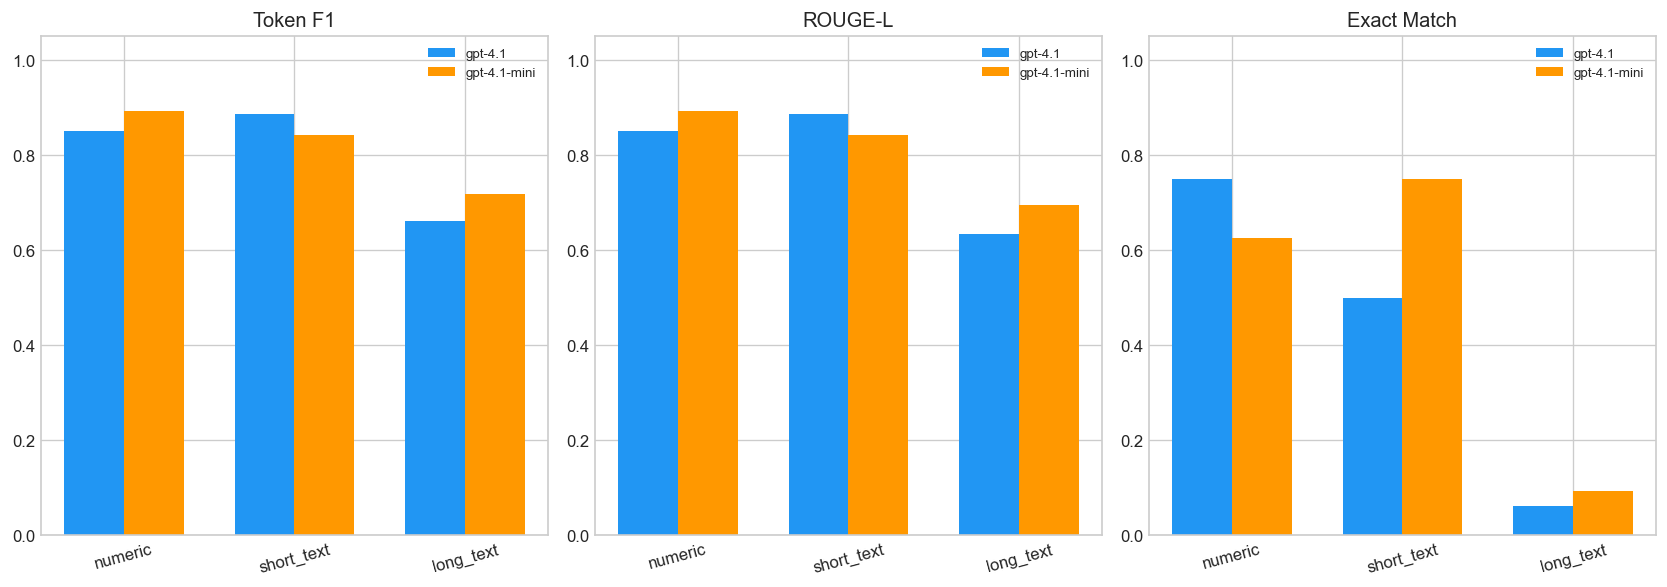

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_to_plot = ['token_f1', 'rouge_l', 'exact_match']
titles = ['Token F1', 'ROUGE-L', 'Exact Match']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    data = {}
    for model in MODELS:
        records = evaluations[model]["records"]
        answered = [r for r in records if not r.get("abstain", False)]
        by_type = {}
        for atype in ['numeric', 'short_text', 'long_text']:
            scores = [r[metric] for r in answered if r.get('answer_type') == atype]
            by_type[atype] = np.mean(scores) if scores else 0
        data[model] = by_type
    
    types = ['numeric', 'short_text', 'long_text']
    x = np.arange(len(types))
    width = 0.35
    
    ax.bar(x - width/2, [data[MODELS[0]][t] for t in types], width, label=MODELS[0], color='#2196F3')
    ax.bar(x + width/2, [data[MODELS[1]][t] for t in types], width, label=MODELS[1], color='#FF9800')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(types, rotation=15)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'performance_by_type.png', bbox_inches='tight')
plt.show()


### 5.3 Numerical Accuracy Deep Dive

In [11]:
for model in MODELS:
    records = evaluations[model]["records"]
    numeric_answered = [
        r for r in records
        if not r.get("abstain") and r.get("numerical_has_numbers")
    ]
    
    print(f"\n{'='*50}")
    print(f"{model} — Numerical Answers ({len(numeric_answered)} samples)")
    print(f"{'='*50}")
    
    if numeric_answered:
        accuracies = [r["numerical_accuracy"] for r in numeric_answered if r["numerical_accuracy"] is not None]
        rel_errors = [r["numerical_mean_rel_error"] for r in numeric_answered if r["numerical_mean_rel_error"] is not None]
        
        print(f"  Mean numerical accuracy:  {np.mean(accuracies):.2%}")
        print(f"  Mean relative error:      {np.mean(rel_errors):.4f}")
        print(f"  Perfect numeric match:    {sum(1 for a in accuracies if a == 1.0)}/{len(accuracies)}")
        
        # Show worst cases
        worst = sorted(numeric_answered, key=lambda r: r.get("numerical_accuracy", 1))[:3]
        print(f"\n  Worst numeric predictions:")
        for r in worst:
            print(f"    [{r['sample_id']}] {r['ticker']}")
            print(f"      Ref: {r['reference_answer'][:80]}")
            print(f"      Pred: {r['predicted_answer'][:80]}")
            print(f"      Num accuracy: {r.get('numerical_accuracy')}")


gpt-4.1 — Numerical Answers (30 samples)
  Mean numerical accuracy:  75.00%
  Mean relative error:      8.0449
  Perfect numeric match:    20/30

  Worst numeric predictions:
    [1] EA
      Ref: The restructuring targets for 2023 focus on prioritizing investments in key grow
      Pred: Investment prioritization towards significant growth prospects and optimization 
      Num accuracy: 0.0
    [29] ABNB
      Ref: The Free Cash Flow of the company in 2023 was $3,837 million.
      Pred: $3,405
      Num accuracy: 0.0
    [35] LVS
      Ref: 'One country, two systems' is the principle under which Macao is governed accord
      Pred: 'one country, two systems'
      Num accuracy: 0.0

gpt-4.1-mini — Numerical Answers (30 samples)
  Mean numerical accuracy:  83.33%
  Mean relative error:      0.4584
  Perfect numeric match:    23/30

  Worst numeric predictions:
    [1] EA
      Ref: The restructuring targets for 2023 focus on prioritizing investments in key grow
      Pred: Investment

### 5.4 Abstention Behaviour

This section evaluates abstention behaviour through two lenses: coverage (how often the model answered) as the primary measure, and should-have-abstained rate (how often the model answered but produced a very poor response) as a diagnostic for over-confidence.




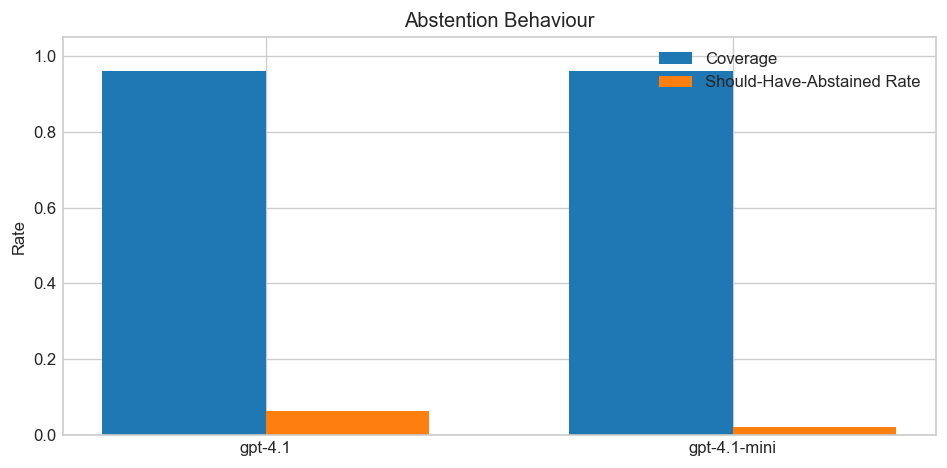

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

coverage = [evaluations[m]["abstention"]["coverage"] for m in MODELS]
sha_rate = [evaluations[m]["abstention"]["should_have_abstained_rate"] for m in MODELS]

x = np.arange(len(MODELS))
width = 0.35

ax.bar(x - width / 2, coverage, width, label="Coverage")
ax.bar(x + width / 2, sha_rate, width, label="Should-Have-Abstained Rate")

ax.set_xticks(x)
ax.set_xticklabels(MODELS, rotation=0)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Rate")
ax.set_title("Abstention Behaviour")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "abstention_behavior.png", bbox_inches="tight")
plt.show()


#### **Note**

1. Both models answered 48 of 50 questions (96% coverage), abstaining on the same 2 cases. The should-have-abstained diagnostic separates them: `gpt-4.1` over-answered on 6% of cases versus 2% for `gpt-4.1-mini`, suggesting mini is better calibrated about when to decline.

2. The should-have-abstained flag is triggered by low lexical overlap, but low overlap does not always indicate a poor answer – concise numeric predictions against more verbose reference answers can score low on Token F1 and ROUGE-L while still being correct. I treated the should-have-abstained rate as a diagnostic signal rather than a primary decision metric.

### 5.5 Failure Case Analysis

Examining the worst predictions helps identify systematic patterns.


In [13]:
for model in MODELS:
    records = evaluations[model]["records"]
    answered = [r for r in records if not r.get("abstain") and not r.get("error")]
    
    # Sort by token F1 (ascending = worst first)
    worst = sorted(answered, key=lambda r: r.get("token_f1", 0))[:5]
    
    print(f"\n{'='*60}")
    print(f"WORST PREDICTIONS — {model}")
    print(f"{'='*60}")
    
    for r in worst:
        print(f"\n  [{r['sample_id']}] {r['ticker']} | type={r['answer_type']} | conf={r.get('confidence')}")
        print(f"  Token F1={r['token_f1']:.3f} | EM={r['exact_match']:.0f} | ROUGE-L={r['rouge_l']:.3f}")
        print(f"  Q: {r['question'][:90]}")
        print(f"  Reference: {r['reference_answer'][:90]}")
        print(f"  Predicted: {r['predicted_answer'][:90]}")
        if r.get("confidence_note"):
            print(f"  Note: {r['confidence_note'][:90]}")



WORST PREDICTIONS — gpt-4.1

  [29] ABNB | type=long_text | conf=5
  Token F1=0.000 | EM=0 | ROUGE-L=0.000
  Q: What was the Free Cash Flow of the company in 2023?
  Reference: The Free Cash Flow of the company in 2023 was $3,837 million.
  Predicted: $3,405
  Note: The context explicitly lists Free Cash Flow as $3,405 for 2023.

  [40] MSFT | type=numeric | conf=5
  Token F1=0.000 | EM=0 | ROUGE-L=0.000
  Q: What was the net cash from operations reported for the year ended June 30, 2023?
  Reference: 87,582 million
  Predicted: $89,035
  Note: The context explicitly lists net cash from operations as 89,035 for the relevant period.

  [8] AVGO | type=long_text | conf=4
  Token F1=0.195 | EM=0 | ROUGE-L=0.195
  Q: What types of companies form the origins of the described global technology leader?
  Reference: The described global technology leader originated from Hewlett-Packard Company, AT&T, LSI 
  Predicted: The origins include companies in computing, telecommunications, semiconduct

## 6. Cost Analysis

Project cost directionally using token usage as a lightweight deployment proxy.


In [14]:
# Illustrative per-1M-token prices used for relative comparison
COSTS = {
    "gpt-4.1": {"input": 2.00, "output": 8.00},
    "gpt-4.1-mini": {"input": 0.40, "output": 1.60},
}

print(f"{'Model':<20} {'Input Tok':>10} {'Output Tok':>12} {'Cost (50)':>10} {'Cost/1K Q':>10} {'Cost/10K Q':>12}")
print("-" * 78)

cost_rows = []
for model in MODELS:
    summary = evaluations[model]["summary"]
    in_tok = summary["total_input_tokens"]
    out_tok = summary["total_output_tokens"]

    cost_50 = (in_tok / 1e6 * COSTS[model]["input"]) + (out_tok / 1e6 * COSTS[model]["output"])
    cost_1k = cost_50 * (1000 / 50)
    cost_10k = cost_50 * (10000 / 50)

    cost_rows.append(
        {
            "Model": model,
            "Cost (50 samples)": cost_50,
            "Projected Cost / 1K Q": cost_1k,
            "Projected Cost / 10K Q": cost_10k,
        }
    )

    print(f"{model:<20} {in_tok:>10,} {out_tok:>12,} ${cost_50:>8.4f} ${cost_1k:>8.2f} ${cost_10k:>10.2f}")

cost_df = pd.DataFrame(cost_rows).set_index("Model")


Model                 Input Tok   Output Tok  Cost (50)  Cost/1K Q   Cost/10K Q
------------------------------------------------------------------------------
gpt-4.1                  32,778        6,313 $  0.1161 $    2.32 $     23.21
gpt-4.1-mini             32,778        6,481 $  0.0235 $    0.47 $      4.70


#### **Note**

Mini also wins decisively on cost (~5x cheaper at 0.47 vs 2.32 USD per 1K queries). Combined with the quality findings in 5.1 and the abstention behaviour in 5.4, the recommendation is unambiguous: gpt-4.1-mini is the better choice for this pipeline. The only scenario where gpt-4.1 would be preferred is if the ~930ms latency difference materially affects user experience.


## 7. Head-to-Head Comparison

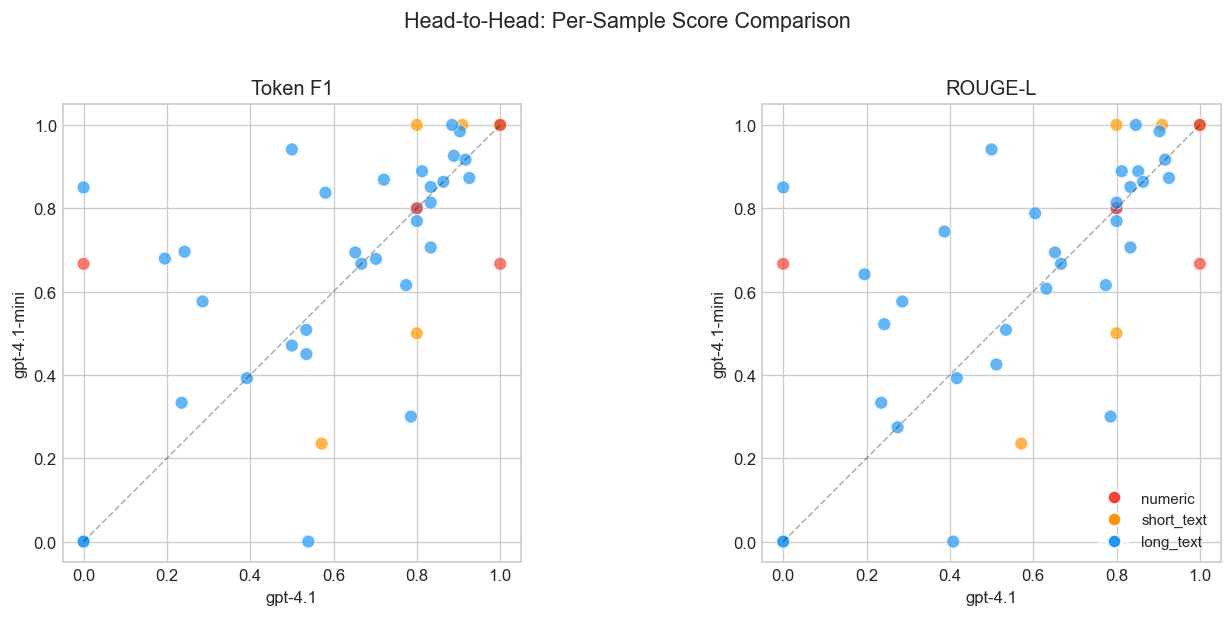


Token F1 wins: gpt-4.1=14, gpt-4.1-mini=17, ties=19


In [15]:
# Merge scores by sample_id for head-to-head comparison
model_a, model_b = MODELS

scores_a = {r["sample_id"]: r for r in evaluations[model_a]["records"]}
scores_b = {r["sample_id"]: r for r in evaluations[model_b]["records"]}

common_ids = set(scores_a.keys()) & set(scores_b.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, title in zip(axes, ["token_f1", "rouge_l"], ["Token F1", "ROUGE-L"]):
    a_scores = []
    b_scores = []
    colors = []
    
    for sid in sorted(common_ids):
        sa = scores_a[sid].get(metric, 0)
        sb = scores_b[sid].get(metric, 0)
        a_scores.append(sa)
        b_scores.append(sb)
        # Color by answer type
        atype = scores_a[sid].get("answer_type", "unknown")
        colors.append({"numeric": "#f44336", "short_text": "#FF9800", "long_text": "#2196F3"}.get(atype, "gray"))
    
    ax.scatter(a_scores, b_scores, c=colors, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)  # diagonal
    ax.set_xlabel(f'{model_a}')
    ax.set_ylabel(f'{model_b}')
    ax.set_title(title)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#f44336', markersize=8, label='numeric'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF9800', markersize=8, label='short_text'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=8, label='long_text'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('Head-to-Head: Per-Sample Score Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'head_to_head.png', bbox_inches='tight')
plt.show()

# Summary: which model won more often?
a_wins = sum(1 for sid in common_ids if scores_a[sid].get("token_f1", 0) > scores_b[sid].get("token_f1", 0))
b_wins = sum(1 for sid in common_ids if scores_b[sid].get("token_f1", 0) > scores_a[sid].get("token_f1", 0))
ties = len(common_ids) - a_wins - b_wins
print(f"\nToken F1 wins: {model_a}={a_wins}, {model_b}={b_wins}, ties={ties}")


#### **Note**

The two models are closely matched on a per-question basis (mini wins 17, gpt-4.1 wins 14, 19 ties), so individual quality differences should be treated as directional rather than definitive. The aggregate metrics in 5.1 show a clearer lead for mini, but the small sample size means the final recommendation should weigh both answer quality and operating cost.


## 8. Export Summary for Slides

In [16]:
# Export a slide-ready comparison table and recommendation summary

export_table = comparison_table.copy()
for model in MODELS:
    export_table.loc[model, "Cost (50 samples)"] = cost_df.loc[model, "Cost (50 samples)"]
    export_table.loc[model, "Projected Cost / 1K Q"] = cost_df.loc[model, "Projected Cost / 1K Q"]
    export_table.loc[model, "Projected Cost / 10K Q"] = cost_df.loc[model, "Projected Cost / 10K Q"]

export_table.to_csv(OUTPUT_DIR / "model_comparison.csv", index_label="Model")
print("Exported model_comparison.csv")

recommendation = {
    "recommended_model": None,
    "rationale": "",
    "models": {},
}

for model in MODELS:
    summary = evaluations[model]["summary"]
    abstention = evaluations[model]["abstention"]
    recommendation["models"][model] = {
        "coverage": abstention["coverage"],
        "token_f1": summary["mean_token_f1"],
        "rouge_l": summary["mean_rouge_l"],
        "numerical_accuracy": summary["mean_numerical_accuracy"],
        "should_have_abstained_rate": abstention["should_have_abstained_rate"],
        "mean_latency_ms": summary["mean_latency_ms"],
        "total_tokens": summary["total_tokens"],
        "projected_cost_per_1k_questions": cost_df.loc[model, "Projected Cost / 1K Q"],
    }

# Recommendation rule — three branches so the rationale always matches the data:
#   (a) primary clearly better on quality   -> recommend primary
#   (b) secondary clearly better on quality -> recommend secondary (cheaper *and* better)
#   (c) genuinely close                     -> recommend secondary on cost grounds
# "Clearly better" thresholds (0.03 Token F1, 0.05 numerical accuracy) are loose on a
# 50-sample evaluation; sub-threshold gaps are treated as directional.
primary_model, secondary_model = MODELS  # gpt-4.1 (more expensive) vs gpt-4.1-mini
primary = recommendation["models"][primary_model]
secondary = recommendation["models"][secondary_model]

quality_gap = (primary["token_f1"] or 0) - (secondary["token_f1"] or 0)
numeric_gap = (primary["numerical_accuracy"] or 0) - (secondary["numerical_accuracy"] or 0)

QUALITY_THRESHOLD = 0.03  # Token F1 gap considered material
NUMERIC_THRESHOLD = 0.05  # Numerical accuracy gap considered material

if quality_gap > QUALITY_THRESHOLD or numeric_gap > NUMERIC_THRESHOLD:
    # (a) primary clearly wins on quality
    recommendation["recommended_model"] = primary_model
    recommendation["rationale"] = (
        f"{primary_model} showed a materially stronger quality advantage on this sample, "
        "which justified the higher operating cost."
    )
elif (-quality_gap) > QUALITY_THRESHOLD or (-numeric_gap) > NUMERIC_THRESHOLD:
    # (b) secondary clearly wins on quality — and is also cheaper
    recommendation["recommended_model"] = secondary_model
    recommendation["rationale"] = (
        f"{secondary_model} matched or exceeded {primary_model} on every quality metric "
        "in this evaluation while costing roughly an order of magnitude less per question, "
        "making it the recommended production choice on both quality and cost."
    )
else:
    # (c) genuinely close — fall back on cost
    recommendation["recommended_model"] = secondary_model
    recommendation["rationale"] = (
        f"The two models were very close on answer quality in this 50-sample evaluation, "
        f"so {secondary_model} is the more pragmatic first production choice because of its lower cost."
    )

with open(OUTPUT_DIR / "recommendation.json", "w", encoding="utf-8") as f:
    json.dump(recommendation, f, indent=2)

print("\nRecommendation:")
print(json.dumps(recommendation, indent=2))


Exported model_comparison.csv

Recommendation:
{
  "recommended_model": "gpt-4.1-mini",
  "rationale": "gpt-4.1-mini matched or exceeded gpt-4.1 on every quality metric in this evaluation while costing roughly an order of magnitude less per question, making it the recommended production choice on both quality and cost.",
  "models": {
    "gpt-4.1": {
      "coverage": 0.96,
      "token_f1": 0.7295,
      "rouge_l": 0.7119,
      "numerical_accuracy": 0.75,
      "should_have_abstained_rate": 0.0625,
      "mean_latency_ms": 1770.54,
      "total_tokens": 39091,
      "projected_cost_per_1k_questions": 2.3212
    },
    "gpt-4.1-mini": {
      "coverage": 0.96,
      "token_f1": 0.767,
      "rouge_l": 0.7521,
      "numerical_accuracy": 0.8333,
      "should_have_abstained_rate": 0.0208,
      "mean_latency_ms": 2705.09,
      "total_tokens": 39259,
      "projected_cost_per_1k_questions": 0.46961600000000003
    }
  }
}


## Recommendation

On this 50-sample evaluation, `gpt-4.1-mini` is the recommended model: it matches or exceeds `gpt-4.1` on every quality metric – Token F1 (0.767 vs 0.730), ROUGE-L (0.752 vs 0.712), Exact Match (29% vs 25%), and numerical accuracy (83% vs 75%) – with coverage tied at 96%, all at roughly one-fifth the cost per question (0.47 vs 2.32 USD per 1K queries). Mini also shows better-calibrated abstention behaviour, over-answering on 2% of cases versus 6% for `gpt-4.1`.

Caveats for production rollout: the numerical accuracy gap (83% vs 75%) rests on only 8 numeric questions and should be treated as directional. Before deploying, I would want a larger evaluation set (~500 questions) stratified by ticker and answer type, plus a calibration check on the abstention threshold. The latency trade-off (mini is ~930ms slower on average, a 53% increase) would become material if it significantly affects user experience.